In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Hospital.csv")

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df.shape

(110527, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [7]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

In [11]:
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [13]:
df = df[df['Age'] > 0]

In [14]:
df['Waiting_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['Waiting_Days']

C:\Users\Admin\AppData\Local\Temp\ipykernel_9128\2016953547.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Waiting_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days


0         -1
1         -1
2         -1
3         -1
4         -1
          ..
110522    34
110523    34
110524    40
110525    40
110526    40
Name: Waiting_Days, Length: 106987, dtype: int64

In [15]:
df['No-show'].value_counts()

No-show
No     85307
Yes    21680
Name: count, dtype: int64

In [16]:
df.groupby('Gender')['No-show'].value_counts()

Gender  No-show
F       No         55843
        Yes        14275
M       No         29464
        Yes         7405
Name: count, dtype: int64

In [17]:
bins=[0,18,35,60,120]
labels = ['Child','Adult','Middle Age','Senior']
df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9128\2030540353.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)


In [19]:
df.groupby('Age_Group')['No-show'].value_counts(normalize=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9128\1090053747.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['No-show'].value_counts(normalize=True)


Age_Group   No-show
Child       No         0.774628
            Yes        0.225372
Adult       No         0.761652
            Yes        0.238348
Middle Age  No         0.808983
            Yes        0.191017
Senior      No         0.847890
            Yes        0.152110
Name: proportion, dtype: float64

In [20]:
df.groupby('SMS_received')['No-show'].value_counts(normalize=True)

SMS_received  No-show
0             No         0.832712
              Yes        0.167288
1             No         0.723348
              Yes        0.276652
Name: proportion, dtype: float64

In [21]:
df.groupby('Waiting_Days')['No-show'].value_counts(normalize=True)

Waiting_Days  No-show
-7            Yes        1.000000
-2            Yes        1.000000
-1            No         0.953141
              Yes        0.046859
 0            No         0.786197
                           ...   
 168          Yes        0.125000
 175          No         0.625000
              Yes        0.375000
 178          No         0.800000
              Yes        0.200000
Name: proportion, Length: 236, dtype: float64

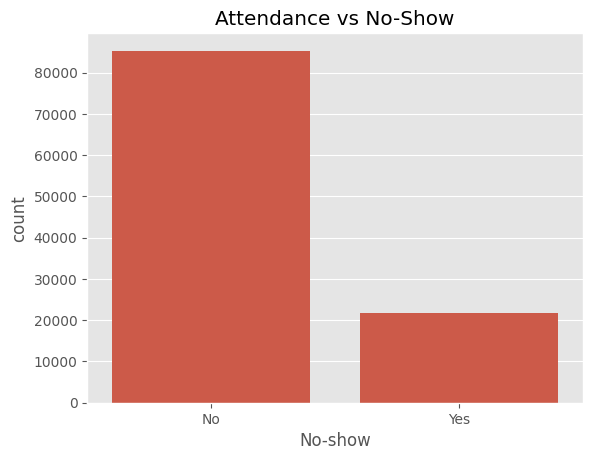

In [22]:
plt.style.use('ggplot')
sns.countplot(data=df,x="No-show")
plt.title("Attendance vs No-Show")
plt.show()

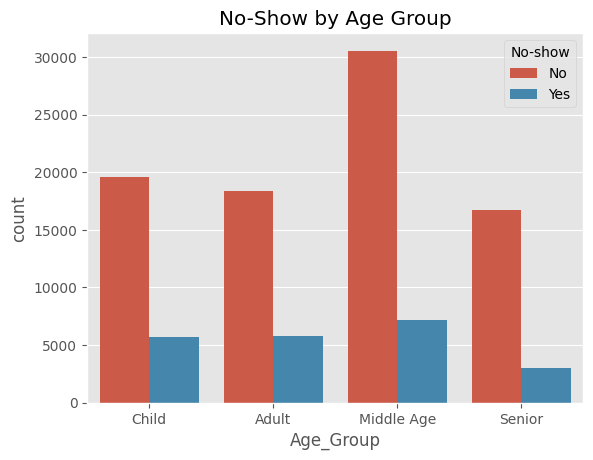

In [25]:
sns.countplot(data=df,x='Age_Group',hue='No-show')
plt.title("No-Show by Age Group")
plt.show()

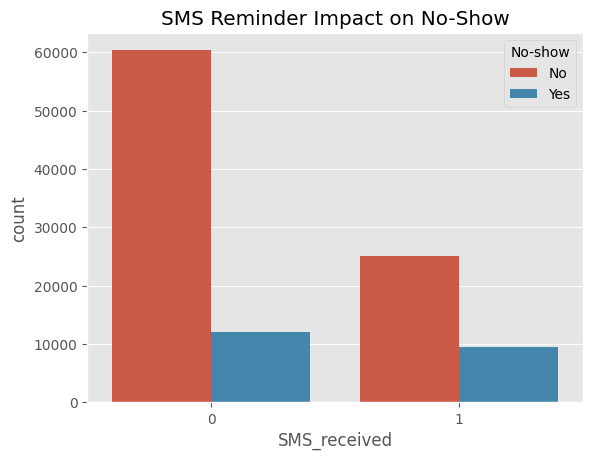

In [26]:
sns.countplot(data=df,x="SMS_received",hue="No-show")
plt.title("SMS Reminder Impact on No-Show")
plt.show()

In [31]:
df.groupby('Hipertension')['No-show'].value_counts(normalize=True)*100

Hipertension  No-show
0             No         78.977766
              Yes        21.022234
1             No         82.698041
              Yes        17.301959
Name: proportion, dtype: float64

This means that those who do not have hypertension only 21 % Patient Attend the appointment and the rest 79 % doesn't show up.And those who have hypertension only 17.3 % come to the hospital and the rest 82.7 % doesn't show up. 

In [32]:
df.groupby('Diabetes')['No-show'].value_counts(normalize=True)*100

Diabetes  No-show
0         No         79.554541
          Yes        20.445459
1         No         81.996727
          Yes        18.003273
Name: proportion, dtype: float64

This means that those who do not have Diabetes only 20 % Patient Attend the appointment and the rest 80 % doesn't show up.And those who have Diabetes only 18 % come to the hospital and the rest 82 % doesn't show up. 

In [33]:
df.groupby('Alcoholism')['No-show'].value_counts(normalize=True)*100

Alcoholism  No-show
0           No         79.732116
            Yes        20.267884
1           No         79.851190
            Yes        20.148810
Name: proportion, dtype: float64

This means that those who do not have Alcoholism Issues only 20 % Patient Attend the appointment and the rest 80 % doesn't show up.And those who have Alcoholism Issues only 20 % come to the hospital and the rest 80 % doesn't show up. 

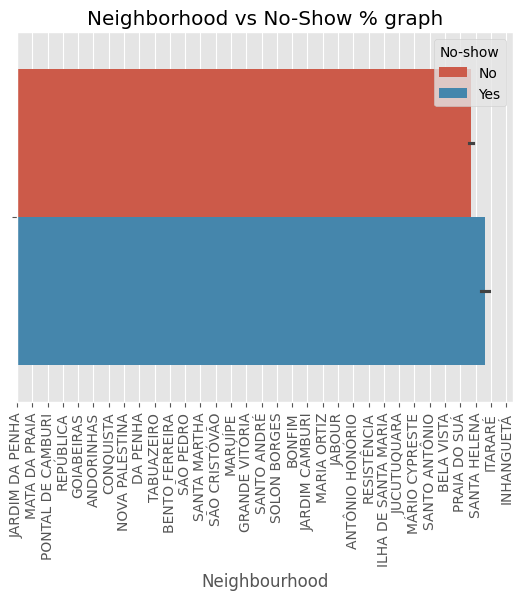

In [41]:
sns.barplot(data=df,hue='No-show',x='Neighbourhood')
plt.title("Neighborhood vs No-Show % graph")
plt.tick_params(rotation=90)
plt.show()

In [42]:
df['ScheduledMonth'] = df['ScheduledDay'].dt.month

In [43]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Waiting_Days,Age_Group,ScheduledMonth
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,-1,Senior,4
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,-1,Middle Age,4
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,-1,Senior,4
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,-1,Child,4
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,-1,Middle Age,4


##### **Summary**

There is no clear reason Behind the no show of patients. The only reason i found is that majority of the patients who do not showed up have no diseases from the given diseases (Hipertension,Diabetes,Alcoholism,Handcap) That is why they don't show up to appointments.